
# One-Click Pipeline: cGAN Generation → Merge Dataset → Train VGG19

This notebook does everything in one run:

1. Loads the **latest cGAN checkpoint**
2. Extracts/loads the generator weights
3. Generates synthetic images for each class
4. Saves them inside `SYNTHETIC (cGAN)` using the same class folder names as `REAL`
5. Creates a new combined dataset folder without altering the original REAL/SYNTHETIC folders
6. Splits real images into:
   - 70% training
   - 20% validation
   - 10% testing
7. Adds synthetic images **only to the training set**
8. Trains **VGG19 transfer learning** using your hyperparameter table:
   - Optimizer: Adam
   - Epochs: 60
   - Initial learning rate: 0.0001
   - L2 regularizer: 0.0001
   - Batch size: 16
   - Dropout rate: 0.10
   - Frozen layers: 12

Validation and testing remain **real-only** for fair evaluation.


## Install Required Dependencies

In [1]:

# Install required dependencies
# On Kaggle, most of these are usually preinstalled.
# This cell is safe to run; it only ensures required packages are available.

import sys
!{sys.executable} -m pip install -q torch torchvision torchaudio scikit-learn pandas matplotlib tqdm pillow


## 1. Imports

In [2]:

import os
import shutil
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torchvision.utils import save_image
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize


## 2. Configuration

In [3]:

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# MAIN PATHS - CHANGE THESE
# =========================
# This should be the folder that contains:
# REAL/
# SYNTHETIC (cGAN)/
# SYNTHETIC (cWGAN)/
base_dataset_dir = r"Philippine Medicinal Plant Leaf Dataset"

real_dataset_dir = os.path.join(base_dataset_dir, "REAL")
synthetic_cgan_dir = os.path.join(base_dataset_dir, "SYNTHETIC (cGAN)")

# Your downloaded latest cGAN checkpoint
cgan_checkpoint_path = r"latest_cgan.pth"

# New folder created by this notebook
combined_dataset_dir = os.path.join(base_dataset_dir, "COMBINED_REAL_cGAN_VGG19")

# =========================
# cGAN GENERATION SETTINGS
# =========================
latent_dim = 100
num_classes = 40
img_size = 128
channels = 3
num_synthetic_per_class = 60

# If True, deletes old synthetic cGAN images before generating new ones.
# If False, skips generation for images that already exist.
regenerate_synthetic = True

# =========================
# REAL DATA SPLIT SETTINGS
# =========================
train_ratio = 0.70
val_ratio = 0.20
test_ratio = 0.10

shuffle_real_split = False
random_seed = 42

# =========================
# VGG19 HYPERPARAMETERS
# =========================
batch_size = 16
epochs = 60
lr = 0.0001
l2_regularizer = 0.0001
dropout_rate = 0.10
frozen_layers = 12

# =========================
# OUTPUTS
# =========================
results_dir = "vgg19_real_cgan_results"
os.makedirs(results_dir, exist_ok=True)

best_model_path = os.path.join(results_dir, "best_vgg19_real_cgan.pth")
checkpoint_path = os.path.join(results_dir, "latest_vgg19_real_cgan_checkpoint.pth")

print("REAL dataset:", real_dataset_dir)
print("SYNTHETIC cGAN dataset:", synthetic_cgan_dir)
print("Combined dataset:", combined_dataset_dir)
print("cGAN checkpoint:", cgan_checkpoint_path)


Using device: cuda
REAL dataset: Philippine Medicinal Plant Leaf Dataset\REAL
SYNTHETIC cGAN dataset: Philippine Medicinal Plant Leaf Dataset\SYNTHETIC (cGAN)
Combined dataset: Philippine Medicinal Plant Leaf Dataset\COMBINED_REAL_cGAN_VGG19
cGAN checkpoint: latest_cgan.pth


## 3. Helper Functions

In [4]:

def is_image_file(filename):
    return filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))

def safe_copy(src, dst):
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)

def clear_folder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

def get_class_names(real_dir):
    class_names = [
        d for d in os.listdir(real_dir)
        if os.path.isdir(os.path.join(real_dir, d))
    ]
    return sorted(class_names)

def count_images(folder):
    if not os.path.exists(folder):
        return 0
    return len([
        f for f in os.listdir(folder)
        if is_image_file(f)
    ])


## 4. Load Class Names

In [5]:

random.seed(random_seed)

class_names = get_class_names(real_dataset_dir)
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:")
for i, name in enumerate(class_names):
    print(i, name)

# Create synthetic class folders if they do not exist
os.makedirs(synthetic_cgan_dir, exist_ok=True)
for class_name in class_names:
    os.makedirs(os.path.join(synthetic_cgan_dir, class_name), exist_ok=True)


Number of classes: 40
Classes:
0 10Coleus scutellarioides(CS)
1 11Phyllanthus niruri(PN)
2 12Corchorus olitorius(CO)
3 13Momordica charantia (MC)
4 14Euphorbia hirta(EH)
5 15Curcuma longa(CL)
6 16Carmona retusa(CR)
7 17Senna alata(SA)
8 18Mentha cordifolia Opiz(MCO)
9 19Capsicum frutescens(CF)
10 1Hibiscus rosa-sinensis(HRS)
11 20Jatropha curcas(JC)
12 21Ocimum basilicum(OB)
13 22Nerium oleander(NO)
14 23Pandanus amaryllifolius(PA)
15 24Aloe barbadensis Miller(ABM)
16 25Lagerstroemia speciosa(LS)
17 26Averrhoea bilimbi(AVB)
18 27Annona muricata(AM)
19 28Citrus aurantiifolia(CIA)
20 29Premna odorata(PO)
21 2Psidium guajava(PG)
22 30Gliricidia sepium(GS)
23 31Citrus sinensis(CIS)
24 32Mangifera indica(MI)
25 33Citrus microcarpa(CM)
26 34Impatiens balsamina(IB)
27 35Arachis hypogaea(AH)
28 36Tamarindus indica(TI)
29 37Leucaena leucocephala(LL)
30 38Ipomoea batatas(IPB)
31 39Manihot esculenta(ME)
32 3Antidesma bunius(AB)
33 40Citrus maxima(CMA)
34 4Vitex negundo(VN)
35 5Moringa oleifera(MO

## 5. cGAN Generator Architecture

In [6]:

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, 100)

        self.fc = nn.Sequential(
            nn.Linear(latent_dim + 100, 1024 * 4 * 4),
            nn.BatchNorm1d(1024 * 4 * 4),
            nn.ReLU(True)
        )

        self.model = nn.Sequential(
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([z, label_input], dim=1)

        out = self.fc(x)
        out = out.view(out.size(0), 1024, 4, 4)

        return self.model(out)


## 6. Load cGAN Generator from Latest Checkpoint

In [7]:

generator = Generator().to(device)

checkpoint = torch.load(cgan_checkpoint_path, map_location=device)

# Supports both full checkpoint format and plain generator state_dict
if isinstance(checkpoint, dict) and "G" in checkpoint:
    generator.load_state_dict(checkpoint["G"])
elif isinstance(checkpoint, dict) and "generator" in checkpoint:
    generator.load_state_dict(checkpoint["generator"])
else:
    generator.load_state_dict(checkpoint)

generator.eval()

print("cGAN generator loaded successfully.")


C:\Users\User\AppData\Local\Temp\ipykernel_13924\2789758013.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cgan_checkpoint_path, map_location=de

cGAN generator loaded successfully.


## 7. Generate Synthetic Images into SYNTHETIC (cGAN) Folder

In [8]:

if regenerate_synthetic:
    print("Clearing existing synthetic cGAN images...")
    for class_name in class_names:
        class_dir = os.path.join(synthetic_cgan_dir, class_name)
        clear_folder(class_dir)

with torch.no_grad():
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(synthetic_cgan_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        existing_count = count_images(class_dir)

        if existing_count >= num_synthetic_per_class and not regenerate_synthetic:
            print(f"Skipping {class_name}; already has {existing_count} images.")
            continue

        print(f"Generating {num_synthetic_per_class} synthetic images for {class_name}...")

        for i in range(num_synthetic_per_class):
            z = torch.randn(1, latent_dim, device=device)
            label = torch.tensor([class_idx], device=device)

            img = generator(z, label)

            save_image(
                (img + 1) / 2,
                os.path.join(class_dir, f"{class_name}_cGAN_{i+1}.png")
            )

print("Synthetic image generation complete.")


Clearing existing synthetic cGAN images...
Generating 60 synthetic images for 10Coleus scutellarioides(CS)...
Generating 60 synthetic images for 11Phyllanthus niruri(PN)...
Generating 60 synthetic images for 12Corchorus olitorius(CO)...
Generating 60 synthetic images for 13Momordica charantia (MC)...
Generating 60 synthetic images for 14Euphorbia hirta(EH)...
Generating 60 synthetic images for 15Curcuma longa(CL)...
Generating 60 synthetic images for 16Carmona retusa(CR)...
Generating 60 synthetic images for 17Senna alata(SA)...
Generating 60 synthetic images for 18Mentha cordifolia Opiz(MCO)...
Generating 60 synthetic images for 19Capsicum frutescens(CF)...
Generating 60 synthetic images for 1Hibiscus rosa-sinensis(HRS)...
Generating 60 synthetic images for 20Jatropha curcas(JC)...
Generating 60 synthetic images for 21Ocimum basilicum(OB)...
Generating 60 synthetic images for 22Nerium oleander(NO)...
Generating 60 synthetic images for 23Pandanus amaryllifolius(PA)...
Generating 60 syn

## 8. Verify Synthetic Image Counts

In [9]:

total_synthetic = 0

for class_name in class_names:
    class_dir = os.path.join(synthetic_cgan_dir, class_name)
    count = count_images(class_dir)
    total_synthetic += count
    print(f"{class_name}: {count}")

print("Total synthetic images:", total_synthetic)


10Coleus scutellarioides(CS): 60
11Phyllanthus niruri(PN): 60
12Corchorus olitorius(CO): 60
13Momordica charantia (MC): 60
14Euphorbia hirta(EH): 60
15Curcuma longa(CL): 60
16Carmona retusa(CR): 60
17Senna alata(SA): 60
18Mentha cordifolia Opiz(MCO): 60
19Capsicum frutescens(CF): 60
1Hibiscus rosa-sinensis(HRS): 60
20Jatropha curcas(JC): 60
21Ocimum basilicum(OB): 60
22Nerium oleander(NO): 60
23Pandanus amaryllifolius(PA): 60
24Aloe barbadensis Miller(ABM): 60
25Lagerstroemia speciosa(LS): 60
26Averrhoea bilimbi(AVB): 60
27Annona muricata(AM): 60
28Citrus aurantiifolia(CIA): 60
29Premna odorata(PO): 60
2Psidium guajava(PG): 60
30Gliricidia sepium(GS): 60
31Citrus sinensis(CIS): 60
32Mangifera indica(MI): 60
33Citrus microcarpa(CM): 60
34Impatiens balsamina(IB): 60
35Arachis hypogaea(AH): 60
36Tamarindus indica(TI): 60
37Leucaena leucocephala(LL): 60
38Ipomoea batatas(IPB): 60
39Manihot esculenta(ME): 60
3Antidesma bunius(AB): 60
40Citrus maxima(CMA): 60
4Vitex negundo(VN): 60
5Moringa 

## 9. Build Combined Dataset

In [10]:

print("Creating combined dataset...")

clear_folder(combined_dataset_dir)

for split in ["train", "val", "test"]:
    for class_name in class_names:
        os.makedirs(os.path.join(combined_dataset_dir, split, class_name), exist_ok=True)

summary = []

for class_name in class_names:
    real_class_dir = os.path.join(real_dataset_dir, class_name)
    synthetic_class_dir = os.path.join(synthetic_cgan_dir, class_name)

    real_files = [
        f for f in os.listdir(real_class_dir)
        if is_image_file(f)
    ]

    real_files = sorted(real_files)

    if shuffle_real_split:
        random.shuffle(real_files)

    n = len(real_files)
    train_end = int(train_ratio * n)
    val_end = int((train_ratio + val_ratio) * n)

    train_files = real_files[:train_end]
    val_files = real_files[train_end:val_end]
    test_files = real_files[val_end:]

    # Copy real images to train/val/test
    for fname in train_files:
        safe_copy(
            os.path.join(real_class_dir, fname),
            os.path.join(combined_dataset_dir, "train", class_name, f"real_{fname}")
        )

    for fname in val_files:
        safe_copy(
            os.path.join(real_class_dir, fname),
            os.path.join(combined_dataset_dir, "val", class_name, f"real_{fname}")
        )

    for fname in test_files:
        safe_copy(
            os.path.join(real_class_dir, fname),
            os.path.join(combined_dataset_dir, "test", class_name, f"real_{fname}")
        )

    # Copy synthetic images ONLY to train
    synthetic_files = []
    if os.path.exists(synthetic_class_dir):
        synthetic_files = [
            f for f in os.listdir(synthetic_class_dir)
            if is_image_file(f)
        ]

        for fname in sorted(synthetic_files):
            safe_copy(
                os.path.join(synthetic_class_dir, fname),
                os.path.join(combined_dataset_dir, "train", class_name, f"synthetic_cgan_{fname}")
            )

    summary.append({
        "class": class_name,
        "real_train": len(train_files),
        "real_val": len(val_files),
        "real_test": len(test_files),
        "synthetic_train": len(synthetic_files),
        "total_train": len(train_files) + len(synthetic_files)
    })

print("Combined dataset created.")


Creating combined dataset...
Combined dataset created.


## 10. Verify Combined Dataset Counts

In [11]:

total_train = total_val = total_test = total_synth = 0

for row in summary:
    total_train += row["total_train"]
    total_val += row["real_val"]
    total_test += row["real_test"]
    total_synth += row["synthetic_train"]

print("Total training images:", total_train)
print("Total validation images:", total_val)
print("Total testing images:", total_test)
print("Total synthetic images added to train:", total_synth)

print("\nSample class summaries:")
for row in summary[:10]:
    print(row)


Total training images: 5873
Total validation images: 969
Total testing images: 529
Total synthetic images added to train: 2400

Sample class summaries:
{'class': '10Coleus scutellarioides(CS)', 'real_train': 84, 'real_val': 23, 'real_test': 13, 'synthetic_train': 60, 'total_train': 144}
{'class': '11Phyllanthus niruri(PN)', 'real_train': 91, 'real_val': 25, 'real_test': 14, 'synthetic_train': 60, 'total_train': 151}
{'class': '12Corchorus olitorius(CO)', 'real_train': 99, 'real_val': 28, 'real_test': 15, 'synthetic_train': 60, 'total_train': 159}
{'class': '13Momordica charantia (MC)', 'real_train': 74, 'real_val': 21, 'real_test': 11, 'synthetic_train': 60, 'total_train': 134}
{'class': '14Euphorbia hirta(EH)', 'real_train': 89, 'real_val': 26, 'real_test': 13, 'synthetic_train': 60, 'total_train': 149}
{'class': '15Curcuma longa(CL)', 'real_train': 70, 'real_val': 19, 'real_test': 11, 'synthetic_train': 60, 'total_train': 130}
{'class': '16Carmona retusa(CR)', 'real_train': 91, 'real

## 11. DataLoaders

In [12]:

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dir = os.path.join(combined_dataset_dir, "train")
val_dir = os.path.join(combined_dataset_dir, "val")
test_dir = os.path.join(combined_dataset_dir, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)


Train images: 5873
Validation images: 969
Test images: 529
Classes: ['10Coleus scutellarioides(CS)', '11Phyllanthus niruri(PN)', '12Corchorus olitorius(CO)', '13Momordica charantia (MC)', '14Euphorbia hirta(EH)', '15Curcuma longa(CL)', '16Carmona retusa(CR)', '17Senna alata(SA)', '18Mentha cordifolia Opiz(MCO)', '19Capsicum frutescens(CF)', '1Hibiscus rosa-sinensis(HRS)', '20Jatropha curcas(JC)', '21Ocimum basilicum(OB)', '22Nerium oleander(NO)', '23Pandanus amaryllifolius(PA)', '24Aloe barbadensis Miller(ABM)', '25Lagerstroemia speciosa(LS)', '26Averrhoea bilimbi(AVB)', '27Annona muricata(AM)', '28Citrus aurantiifolia(CIA)', '29Premna odorata(PO)', '2Psidium guajava(PG)', '30Gliricidia sepium(GS)', '31Citrus sinensis(CIS)', '32Mangifera indica(MI)', '33Citrus microcarpa(CM)', '34Impatiens balsamina(IB)', '35Arachis hypogaea(AH)', '36Tamarindus indica(TI)', '37Leucaena leucocephala(LL)', '38Ipomoea batatas(IPB)', '39Manihot esculenta(ME)', '3Antidesma bunius(AB)', '40Citrus maxima(CMA)

## 12. Build VGG19 Transfer Learning Model

In [13]:

try:
    weights = models.VGG19_Weights.IMAGENET1K_V1
    model = models.vgg19(weights=weights)
except Exception:
    model = models.vgg19(pretrained=True)

# Freeze first 12 parameter groups according to your table.
count = 0
for param in model.features.parameters():
    if count < frozen_layers:
        param.requires_grad = False
        count += 1
    else:
        param.requires_grad = True

num_features = model.classifier[6].in_features

model.classifier[6] = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(num_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr,
    weight_decay=l2_regularizer
)

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable parameters: 138588712


## 13. Train VGG19 with Best Model Saving

In [14]:

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0.0
start_epoch = 0
resume_vgg_training = False

if resume_vgg_training and os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])

    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]

    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    train_accuracies = ckpt.get("train_accuracies", [])
    val_accuracies = ckpt.get("val_accuracies", [])

    print(f"Resuming VGG19 training from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    model.train()

    running_loss = 0.0
    correct_train = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for imgs, labels in loop:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(train_loss=f"{loss.item():.4f}")

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = correct_val / total_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved. Val Acc: {best_val_acc:.4f}")

    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }, checkpoint_path)

print("VGG19 training finished.")
print("Best validation accuracy:", best_val_acc)


Epoch [1/60]: 100%|███████████████████████████████████████████████| 368/368 [07:33<00:00,  1.23s/it, train_loss=0.0000]


Epoch 1/60
Train Loss: 0.7391 | Train Acc: 0.7981
Val Loss:   0.3817 | Val Acc:   0.8824
Best model saved. Val Acc: 0.8824


Epoch [2/60]: 100%|███████████████████████████████████████████████| 368/368 [06:19<00:00,  1.03s/it, train_loss=0.0000]


Epoch 2/60
Train Loss: 0.1280 | Train Acc: 0.9649
Val Loss:   0.1970 | Val Acc:   0.9443
Best model saved. Val Acc: 0.9443


Epoch [3/60]: 100%|███████████████████████████████████████████████| 368/368 [06:23<00:00,  1.04s/it, train_loss=0.0001]


...

Epoch 58/60
Train Loss: 0.0024 | Train Acc: 0.9998
Val Loss:   0.3885 | Val Acc:   0.9360


Epoch [59/60]: 100%|██████████████████████████████████████████████| 368/368 [06:12<00:00,  1.01s/it, train_loss=0.0000]


Epoch 59/60
Train Loss: 0.0421 | Train Acc: 0.9910
Val Loss:   0.3000 | Val Acc:   0.9278


Epoch [60/60]: 100%|██████████████████████████████████████████████| 368/368 [06:08<00:00,  1.00s/it, train_loss=0.0001]


Epoch 60/60
Train Loss: 0.0284 | Train Acc: 0.9917
Val Loss:   0.3282 | Val Acc:   0.9391
VGG19 training finished.
Best validation accuracy: 0.9649122807017544


## 14. Plot Training Curves

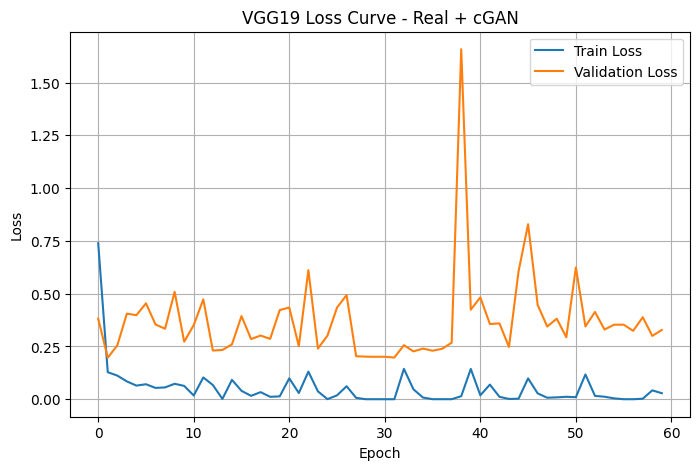

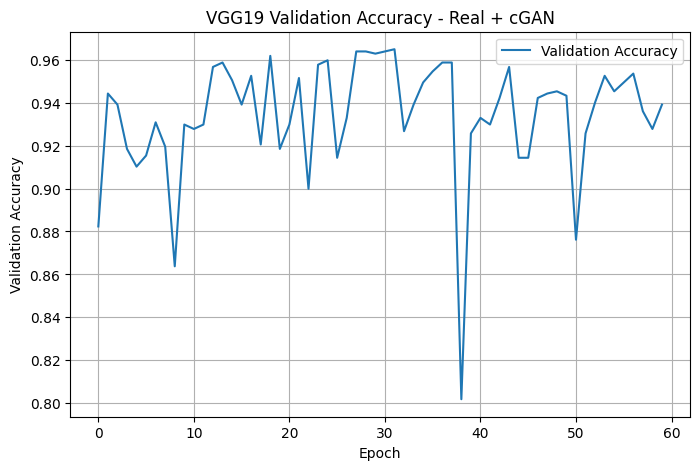

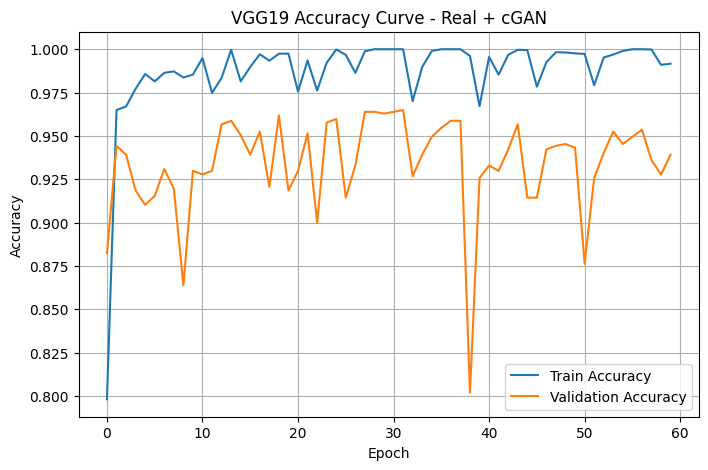

In [15]:

# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG19 Loss Curve - Real + cGAN")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

# Plot Validation Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("VGG19 Validation Accuracy - Real + cGAN")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "validation_accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

# Plot Train and Validation Accuracy Together
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG19 Accuracy Curve - Real + cGAN")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()


## 15. Test Best VGG19 Model

In [16]:

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_loss = 0.0

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        test_loss += loss.item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

avg_test_loss = test_loss / len(test_loader)

test_accuracy = accuracy_score(all_labels, all_preds)
test_precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
test_recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
test_f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

test_precision_weighted = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
test_recall_weighted = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
test_f1_weighted = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("===== TEST METRICS =====")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision (Macro): {test_precision_macro:.4f}")
print(f"Recall (Macro): {test_recall_macro:.4f}")
print(f"F1-score (Macro): {test_f1_macro:.4f}")
print(f"Precision (Weighted): {test_precision_weighted:.4f}")
print(f"Recall (Weighted): {test_recall_weighted:.4f}")
print(f"F1-score (Weighted): {test_f1_weighted:.4f}")

metrics_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-score (Weighted)"
    ],
    "Value": [
        avg_test_loss,
        test_accuracy,
        test_precision_macro,
        test_recall_macro,
        test_f1_macro,
        test_precision_weighted,
        test_recall_weighted,
        test_f1_weighted
    ]
})

metrics_path = os.path.join(results_dir, "vgg19_test_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved metrics to:", metrics_path)
metrics_df


C:\Users\User\AppData\Local\Temp\ipykernel_13924\1290830726.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio

===== TEST METRICS =====
Test Loss: 0.3030
Accuracy: 0.9509
Precision (Macro): 0.9531
Recall (Macro): 0.9506
F1-score (Macro): 0.9465
Precision (Weighted): 0.9548
Recall (Weighted): 0.9509
F1-score (Weighted): 0.9474
Saved metrics to: vgg19_real_cgan_results\vgg19_test_metrics.csv


,Metric,Value
0,Test Loss,0.303043
1,Accuracy,0.950851
2,Precision (Macro),0.953070
3,Recall (Macro),0.950584
4,F1-score (Macro),0.946461
5,Precision (Weighted),0.954848
6,Recall (Weighted),0.950851
7,F1-score (Weighted),0.947365


## 16. Classification Report

In [17]:

report = classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_path = os.path.join(results_dir, "classification_report.csv")
report_df.to_csv(report_path)

print(report_df)
print("Saved classification report to:", report_path)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=test_dataset.classes, columns=test_dataset.classes)
cm_path = os.path.join(results_dir, "confusion_matrix.csv")
cm_df.to_csv(cm_path)
print("Saved confusion matrix to:", cm_path)


                                precision    recall  f1-score     support
10Coleus scutellarioides(CS)     0.684211  1.000000  0.812500   13.000000
11Phyllanthus niruri(PN)         1.000000  1.000000  1.000000   14.000000
12Corchorus olitorius(CO)        0.933333  0.933333  0.933333   15.000000
13Momordica charantia (MC)       1.000000  1.000000  1.000000   11.000000
14Euphorbia hirta(EH)            0.928571  1.000000  0.962963   13.000000
15Curcuma longa(CL)              1.000000  1.000000  1.000000   11.000000
16Carmona retusa(CR)             1.000000  1.000000  1.000000   14.000000
17Senna alata(SA)                1.000000  1.000000  1.000000   12.000000
18Mentha cordifolia Opiz(MCO)    1.000000  1.000000  1.000000   11.000000
19Capsicum frutescens(CF)        1.000000  1.000000  1.000000   13.000000
1Hibiscus rosa-sinensis(HRS)     1.000000  1.000000  1.000000   12.000000
20Jatropha curcas(JC)            1.000000  1.000000  1.000000   15.000000
21Ocimum basilicum(OB)           1.000

## ROC-AUC Curve

ROC-AUC Micro: 0.9981
ROC-AUC Macro: 0.9984
Saved ROC-AUC scores to: vgg19_real_cgan_results\roc_auc_scores.csv


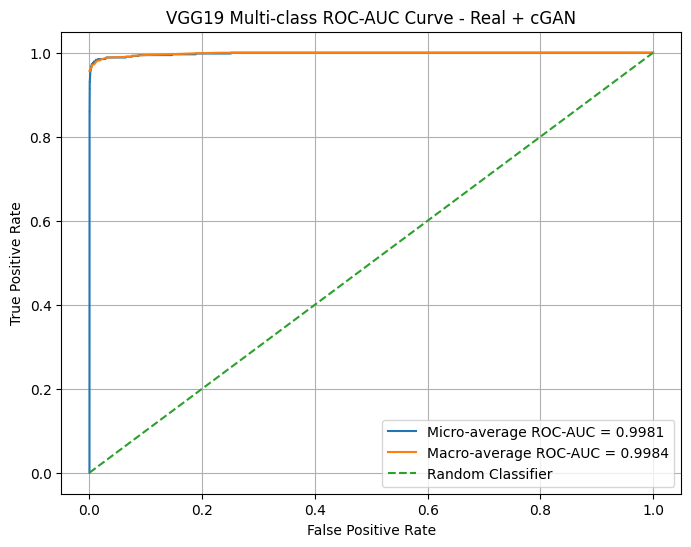

Saved ROC-AUC curve to: vgg19_real_cgan_results\roc_auc_curve.png


In [18]:

# Multi-class ROC-AUC curve using one-vs-rest strategy.
# This plots micro-average and macro-average ROC curves.

n_classes = len(test_dataset.classes)
y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for class_idx in range(n_classes):
    fpr[class_idx], tpr[class_idx], _ = roc_curve(y_true_bin[:, class_idx], all_probs[:, class_idx])
    roc_auc[class_idx] = auc(fpr[class_idx], tpr[class_idx])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[class_idx] for class_idx in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for class_idx in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[class_idx], tpr[class_idx])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"ROC-AUC Micro: {roc_auc['micro']:.4f}")
print(f"ROC-AUC Macro: {roc_auc['macro']:.4f}")

roc_auc_df = pd.DataFrame({
    "Metric": ["ROC-AUC Micro", "ROC-AUC Macro"],
    "Value": [roc_auc["micro"], roc_auc["macro"]]
})
roc_auc_path = os.path.join(results_dir, "roc_auc_scores.csv")
roc_auc_df.to_csv(roc_auc_path, index=False)
print("Saved ROC-AUC scores to:", roc_auc_path)

plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"], label=f"Micro-average ROC-AUC = {roc_auc['micro']:.4f}")
plt.plot(fpr["macro"], tpr["macro"], label=f"Macro-average ROC-AUC = {roc_auc['macro']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG19 Multi-class ROC-AUC Curve - Real + cGAN")
plt.legend(loc="lower right")
plt.grid(True)

roc_curve_path = os.path.join(results_dir, "roc_auc_curve.png")
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved ROC-AUC curve to:", roc_curve_path)


## 17. Zip Results

In [19]:

shutil.make_archive(results_dir, "zip", results_dir)
print("Zipped results:", results_dir + ".zip")


Zipped results: vgg19_real_cgan_results.zip
